## PREPARATION

In [3]:
import sys
import warnings

sys.path.append('..') 

import pandas as pd
import numpy as np
import optuna
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, classification_report

from src.feature_selection import (
    ovr_select_features_xgb, 
    ovr_select_features_rfe, 
    ovr_select_features_mi
)

SEED = 42
TARGET_NAMES = ['Dropout', 'Enrolled', 'Graduate']
warnings.filterwarnings('ignore') 

df_clean = pd.read_csv("../data/processed/data_final.csv")
y = df_clean['Target']
X = df_clean.drop(columns=['Target'])

ALL_FEATURES = X.columns.tolist()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
y_train_clean = y_train  


CAT_COLS = ['Marital status', 'Application mode', 'Course', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"]
for col in CAT_COLS:
    X_train_raw[col] = X_train_raw[col].astype(str)
    X_test_raw[col] = X_test_raw[col].astype(str)

te = TargetEncoder(cols=CAT_COLS, smoothing=10)
X_tr = te.fit_transform(X_train_raw, y_train)
X_te = te.transform(X_test_raw)

sc = StandardScaler()
X_tr_sc = pd.DataFrame(sc.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
X_te_sc = pd.DataFrame(sc.transform(X_te),     columns=X_te.columns, index=X_te.index)

X_tr_np = X_tr_sc.values
y_tr_np = y_train_clean.values

print(f"Train Dimension : {X_tr_np.shape} | Test Dimension : {X_te_sc.shape}")

Train Dimension : (2863, 53) | Test Dimension : (716, 53)


## XGBOOST - Enrolled Specialist

In [4]:

from xgboost import XGBClassifier

### OvR Feature Selection

In [5]:
xgb_feat_idx   = ovr_select_features_xgb(X_tr_np, y_tr_np, target_class=1, n_top=20)
xgb_feat_names = [ALL_FEATURES[i] for i in xgb_feat_idx]
print(f"XGB selected {len(xgb_feat_idx)} features (Enrolled OvR):")
print(xgb_feat_names)

XGB selected 20 features (Enrolled OvR):
['Course', 'Previous qualification', "Mother's qualification", "Mother's occupation", 'Debtor', 'Tuition fees up to date', 'Age at enrollment', 'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (enrolled)', 'Unemployment rate', 'Pass_Rate_Sem1', 'Pass_Rate_Sem2', 'Academic_Momentum', 'Total_Approved', 'Overall_Pass_Rate', 'Load_Change', 'Financial_Stress', 'Dropout_Risk', 'Grade_x_PassRate', 'Enrollment_Stability']


### Optuna

In [6]:

def obj_xgb(trial):
    p = {
        'n_estimators'    : trial.suggest_int('n_estimators', 200, 800),
        'max_depth'       : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma'           : trial.suggest_float('gamma', 0, 5),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'objective': 'multi:softprob', 'num_class': 3,
        'tree_method': 'hist', 'random_state': SEED, 'n_jobs': 1, 'eval_metric': 'mlogloss',
    }
    enrolled_w = trial.suggest_float('enrolled_weight', 4.0, 20.0)
    dropout_w  = trial.suggest_float('dropout_weight',  0.5, 1.5)
    graduate_w = trial.suggest_float('graduate_weight', 0.5, 1.5)

    X_sub = X_tr_np[:, xgb_feat_idx]
    skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = []
    for ti, vi in skf.split(X_sub, y_tr_np):
        w = compute_sample_weight({0: dropout_w, 1: enrolled_w, 2: graduate_w}, y_tr_np[ti])
        m = XGBClassifier(**p)
        m.fit(X_sub[ti], y_tr_np[ti], sample_weight=w)
        scores.append(f1_score(y_tr_np[vi], m.predict(X_sub[vi]), average=None)[1])
    return np.mean(scores)


### Optimize Optuna

In [7]:
study_xgb = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=15)
)
study_xgb.optimize(obj_xgb, n_trials=150, show_progress_bar=True)



[I 2026-05-21 21:36:56,234] A new study created in memory with name: no-name-e1b814c0-988e-4c31-a792-2c8d6d58b935


  0%|          | 0/150 [00:00<?, ?it/s]

[I 2026-05-21 21:37:03,031] Trial 0 finished with value: 0.6047016807766867 and parameters: {'n_estimators': 568, 'max_depth': 5, 'learning_rate': 0.005946373907180185, 'min_child_weight': 4, 'subsample': 0.6687749034591272, 'colsample_bytree': 0.8334645041948447, 'gamma': 0.182778168421327, 'reg_alpha': 1.9123412506828727e-05, 'reg_lambda': 4.070770717645376, 'enrolled_weight': 8.135876185938134, 'dropout_weight': 0.5012590346485547, 'graduate_weight': 0.7792516798648099}. Best is trial 0 with value: 0.6047016807766867.
[I 2026-05-21 21:37:10,380] Trial 1 finished with value: 0.6567979817254332 and parameters: {'n_estimators': 696, 'max_depth': 7, 'learning_rate': 0.011164268104348438, 'min_child_weight': 9, 'subsample': 0.7970072216410259, 'colsample_bytree': 0.8956414107786888, 'gamma': 2.680873906776835, 'reg_alpha': 7.767718533893232e-08, 'reg_lambda': 4.965378198291857e-05, 'enrolled_weight': 13.080609584051214, 'dropout_weight': 1.4836976710302592, 'graduate_weight': 0.885636235

### Optuna Result

In [8]:
from rich.console import Console
from rich.table import Table

console = Console()

table = Table(title=f"OPTUNA TUNING SUMMARY (Best F1: {study_xgb.best_value:.4f})", title_style="bold green")

table.add_column("Hyperparameter", justify="left", style="cyan", no_wrap=True)
table.add_column("Value / Status", justify="left", style="magenta")

for key, value in study_xgb.best_params.items():
    if 'weight' in key:
        table.add_row(key, f"{value:.4f} [yellow](Class Weight)[/yellow]")
    else:
        table.add_row(key, str(value))

console.print(table)

best_params_xgb  = study_xgb.best_params.copy()
enrolled_w_final = best_params_xgb.pop('enrolled_weight')
dropout_w_xgb    = best_params_xgb.pop('dropout_weight')
graduate_w_xgb   = best_params_xgb.pop('graduate_weight')

   OPTUNA TUNING SUMMARY (Best F1: 0.7250)   
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Hyperparameter   ┃ Value / Status         ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ n_estimators     │ 758                    │
│ max_depth        │ 4                      │
│ learning_rate    │ 0.042848277897862976   │
│ min_child_weight │ 1.0000 (Class Weight)  │
│ subsample        │ 0.7386203873891873     │
│ colsample_bytree │ 0.8718152392103218     │
│ gamma            │ 0.4251398349490388     │
│ reg_alpha        │ 3.159194525451997e-07  │
│ reg_lambda       │ 2.009165466358088e-08  │
│ enrolled_weight  │ 19.2223 (Class Weight) │
│ dropout_weight   │ 1.1563 (Class Weight)  │
│ graduate_weight  │ 1.3214 (Class Weight)  │
└──────────────────┴────────────────────────┘

### Parameter Initialization & Training Model

In [9]:
XGB_PARAMS = {
    **best_params_xgb,
    'objective': 'multi:softprob', 'num_class': 3,
    'tree_method': 'hist', 'random_state': SEED, 'n_jobs': -1, 'eval_metric': 'mlogloss',
}
Xtr_xgb = X_tr_np[:, xgb_feat_idx]
Xte_xgb = X_te_sc.values[:, xgb_feat_idx]
w_xgb   = compute_sample_weight({0: dropout_w_xgb, 1: enrolled_w_final, 2: graduate_w_xgb}, y_tr_np)

best_xgb = XGBClassifier(**XGB_PARAMS)
best_xgb.fit(Xtr_xgb, y_tr_np, sample_weight=w_xgb)



,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8718152392103218
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import l

### Model Evaluation

XGBoost — Enrolled Specialist Evaluation Metrics
Accuracy  : 0.9162
Log Loss  : 0.2675
ROC-AUC   : 0.9790 (One-vs-Rest Macro)
------------------------------------------------------------
F1 per class -> Dropout:0.9212  Enrolled:0.7081  Graduate:0.9531
F1 Macro     : 0.8608

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.95      0.89      0.92       216
    Enrolled       0.65      0.78      0.71        73
    Graduate       0.96      0.95      0.95       427

    accuracy                           0.92       716
   macro avg       0.85      0.88      0.86       716
weighted avg       0.92      0.92      0.92       716

------------------------------------------------------------
Confusion Matrix (Text):
[[193  13  10]
 [  7  57   9]
 [  3  18 406]]


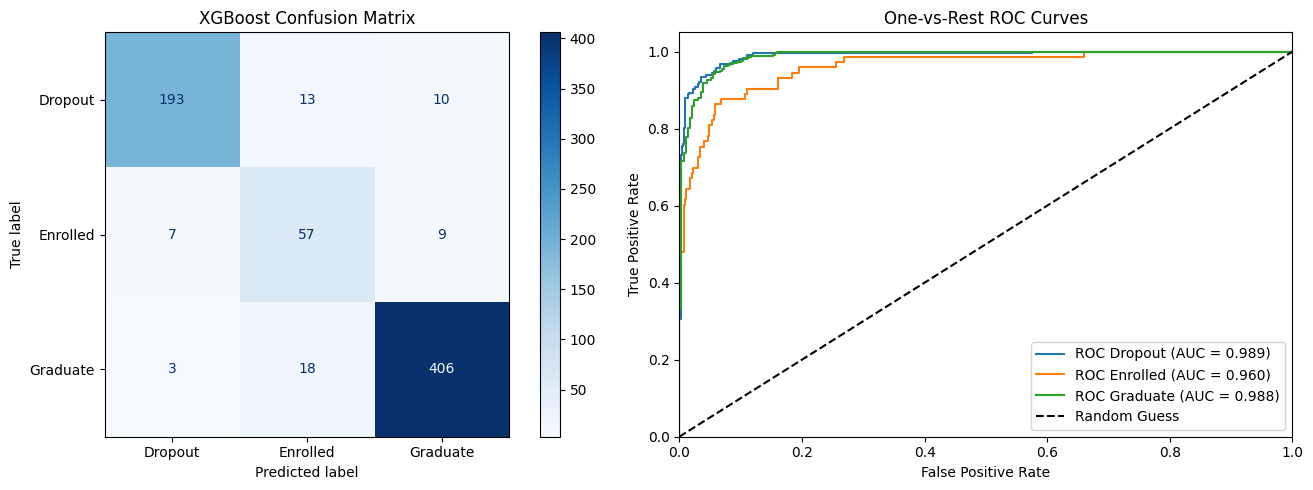

['../models/specialist_enrolled_xgb.pkl']

In [11]:
from sklearn.metrics import log_loss, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt 

y_pred_xgb  = best_xgb.predict(Xte_xgb)
y_proba_xgb = best_xgb.predict_proba(Xte_xgb)

loss_xgb    = log_loss(y_test, y_proba_xgb)
roc_auc_ovr = roc_auc_score(y_test, y_proba_xgb, multi_class='ovr', average='macro')

print("="*60)
print("XGBoost — Enrolled Specialist Evaluation Metrics")
print("="*60)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Log Loss  : {loss_xgb:.4f}")
print(f"ROC-AUC   : {roc_auc_ovr:.4f} (One-vs-Rest Macro)")
print("-" * 60)

f1_xgb = f1_score(y_test, y_pred_xgb, average=None)
print(f"F1 per class -> Dropout:{f1_xgb[0]:.4f}  Enrolled:{f1_xgb[1]:.4f}  Graduate:{f1_xgb[2]:.4f}")
print(f"F1 Macro     : {f1_score(y_test, y_pred_xgb, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=TARGET_NAMES))

print("-" * 60)
print("Confusion Matrix (Text):")
cm = confusion_matrix(y_test, y_pred_xgb)
print(cm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES)
disp.plot(cmap=plt.cm.Blues, ax=axes[0], values_format='d')
axes[0].set_title("XGBoost Confusion Matrix")

y_test_bin = pd.get_dummies(y_test).values
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_xgb[:, i])
    roc_auc     = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'ROC {TARGET_NAMES[i]} (AUC = {roc_auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('One-vs-Rest ROC Curves')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig('../output/xgb_specialist_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

import joblib
joblib.dump(best_xgb, '../models/specialist_enrolled_xgb.pkl')

## SVM - Graduate Specialist

In [12]:
from sklearn.svm import SVC

### OvR Feature Selection

In [13]:

SVM_N_FEAT    = 15
SVM_EXCLUDE   = ['Zero_Activity_Sem2', 'Displaced', 'Educational special needs',
                 'International', 'Gender', 'Debtor', 'Scholarship holder',
                 'Tuition fees up to date']
svm_cand_idx  = [i for i, f in enumerate(ALL_FEATURES) if f not in SVM_EXCLUDE]

svm_rel_idx   = ovr_select_features_rfe(X_tr_np[:, svm_cand_idx], y_tr_np, target_class=2, n_top=SVM_N_FEAT)
svm_feat_idx  = [svm_cand_idx[i] for i in svm_rel_idx]
svm_feat_names = [ALL_FEATURES[i] for i in svm_feat_idx]

print(f"SVM selected {len(svm_feat_idx)} features (Graduate OvR):")
print(svm_feat_names)

SVM selected 15 features (Graduate OvR):
['Course', 'Nacionality', "Father's qualification", "Mother's occupation", 'Curricular units 1st sem (enrolled)', 'Curricular units 2nd sem (grade)', 'Pass_Rate_Sem1', 'Pass_Rate_Sem2', 'Total_Approved', 'Overall_Pass_Rate', 'Financial_Stress', 'Dropout_Risk', 'Credit_Completion', 'Grade_x_PassRate', 'Active_No_Graduate']


### Optuna

In [14]:

def obj_svm(trial):
    p = {
        'C'     : trial.suggest_float('C', 1e-1, 1e3, log=True),
        'gamma' : trial.suggest_float('gamma', 1e-4, 1e1, log=True),
        'kernel': trial.suggest_categorical('kernel', ['rbf', 'poly']),
    }
    graduate_w = trial.suggest_float('graduate_weight', 1.0, 5.0)

    X_sub = X_tr_np[:, svm_feat_idx]
    skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = []
    for ti, vi in skf.split(X_sub, y_tr_np):
        w = compute_sample_weight({0: 1.0, 1: 1.0, 2: graduate_w}, y_tr_np[ti])
        m = SVC(**p, probability=True, random_state=SEED, cache_size=2000)
        m.fit(X_sub[ti], y_tr_np[ti], sample_weight=w)
        # Indeks [2] untuk mengambil metrik kelas Graduate
        scores.append(f1_score(y_tr_np[vi], m.predict(X_sub[vi]), average=None)[2])
    return np.mean(scores)



### Optimize Optuna

In [15]:


study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(obj_svm, n_trials=60, show_progress_bar=True)



[I 2026-05-21 22:03:27,857] A new study created in memory with name: no-name-285b86d2-8531-4953-95de-6ec7ebb5ae4c


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-05-21 22:03:29,589] Trial 0 finished with value: 0.9569646882329158 and parameters: {'C': 41.61532962983596, 'gamma': 0.05396988277416652, 'kernel': 'rbf', 'graduate_weight': 1.6643076417048257}. Best is trial 0 with value: 0.9569646882329158.
[I 2026-05-21 22:03:30,820] Trial 1 finished with value: 0.9097257108100312 and parameters: {'C': 0.43544570106543834, 'gamma': 0.09334864290376076, 'kernel': 'poly', 'graduate_weight': 1.008789053955284}. Best is trial 0 with value: 0.9569646882329158.
[I 2026-05-21 22:03:40,624] Trial 2 finished with value: 0.8075999668673839 and parameters: {'C': 434.58765655987946, 'gamma': 9.61730333337189, 'kernel': 'rbf', 'graduate_weight': 2.3218195528671584}. Best is trial 0 with value: 0.9569646882329158.
[I 2026-05-21 22:03:41,830] Trial 3 finished with value: 0.9536356928907939 and parameters: {'C': 3.9399496327444465, 'gamma': 0.02078378857942074, 'kernel': 'rbf', 'graduate_weight': 2.104235393998931}. Best is trial 0 with value: 0.9569646882

### Optuna Result

In [16]:
from rich.console import Console
from rich.table import Table

console = Console()

table = Table(title=f"OPTUNA TUNING SUMMARY (Best F1-Graduate: {study_svm.best_value:.4f})", title_style="bold purple")

table.add_column("Hyperparameter", justify="left", style="cyan", no_wrap=True)
table.add_column("Value / Status", justify="left", style="magenta")

for key, value in study_svm.best_params.items():
    if 'weight' in key:
        table.add_row(key, f"{value:.4f} [yellow](Class Weight)[/yellow]")
    else:
        val_str = f"{value:.4f}" if isinstance(value, float) else str(value)
        table.add_row(key, val_str)

console.print(table)

best_params_svm  = study_svm.best_params.copy()
graduate_w_final = best_params_svm.pop('graduate_weight', 4.0)

 OPTUNA TUNING SUMMARY (Best F1-Graduate:  
                  0.9607)                  
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Hyperparameter  ┃ Value / Status        ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ C               │ 29.7557               │
│ gamma           │ 0.0063                │
│ kernel          │ rbf                   │
│ graduate_weight │ 1.0655 (Class Weight) │
└─────────────────┴───────────────────────┘

### Training Model

In [17]:
SVM_PARAMS = {**best_params_svm, 'probability': True, 'random_state': SEED, 'cache_size': 2000}
Xtr_svm    = X_tr_np[:, svm_feat_idx]
Xte_svm    = X_te_sc.values[:, svm_feat_idx]
w_svm      = compute_sample_weight({0: 1.0, 1: 1.0, 2: graduate_w_final}, y_tr_np)

best_svm = SVC(**SVM_PARAMS)
best_svm.fit(Xtr_svm, y_tr_np, sample_weight=w_svm)



,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",29.75574124609808
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.006271796715178312
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",2000
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Model Evaluation

SVM — Graduate Specialist Evaluation Metrics
Accuracy  : 0.9050
Log Loss  : 0.2557
ROC-AUC   : 0.9672 (One-vs-Rest Macro)
------------------------------------------------------------
F1 per class -> Dropout:0.8993  Enrolled:0.5785  Graduate:0.9525
F1 Macro     : 0.8101

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.91      0.89      0.90       216
    Enrolled       0.73      0.48      0.58        73
    Graduate       0.92      0.99      0.95       427

    accuracy                           0.91       716
   macro avg       0.85      0.78      0.81       716
weighted avg       0.90      0.91      0.90       716

------------------------------------------------------------
Confusion Matrix (Text):
[[192   9  15]
 [ 17  35  21]
 [  2   4 421]]


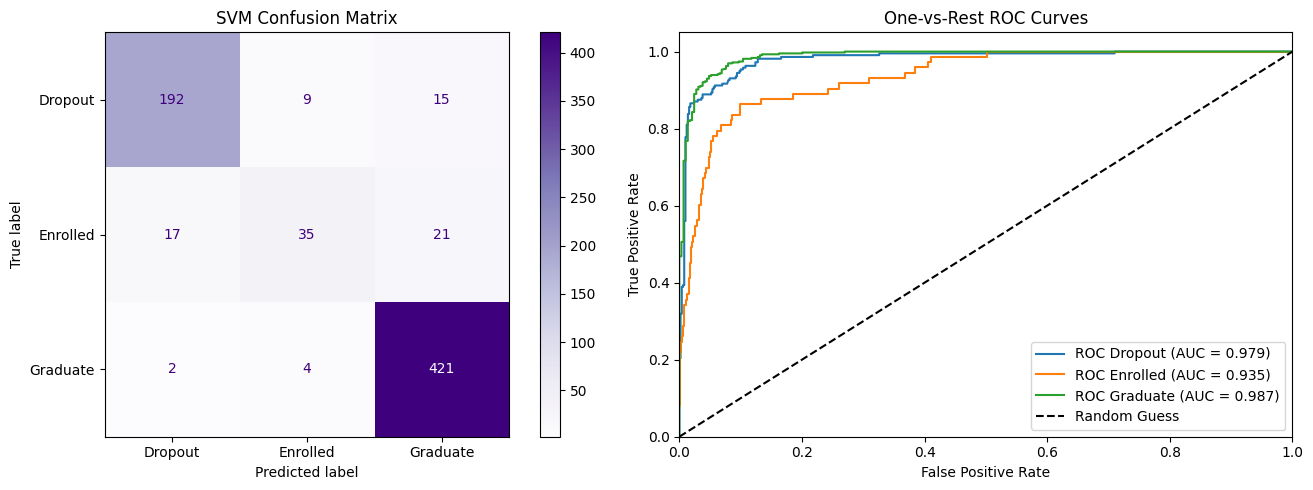

['../models/specialist_graduate_svm.pkl']

In [18]:
from sklearn.metrics import log_loss, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt 

y_pred_svm  = best_svm.predict(Xte_svm)
y_proba_svm = best_svm.predict_proba(Xte_svm)

loss_svm    = log_loss(y_test, y_proba_svm)
roc_auc_ovr = roc_auc_score(y_test, y_proba_svm, multi_class='ovr', average='macro')

print("="*60)
print("SVM — Graduate Specialist Evaluation Metrics")
print("="*60)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Log Loss  : {loss_svm:.4f}")
print(f"ROC-AUC   : {roc_auc_ovr:.4f} (One-vs-Rest Macro)")
print("-" * 60)

f1_svm = f1_score(y_test, y_pred_svm, average=None)
print(f"F1 per class -> Dropout:{f1_svm[0]:.4f}  Enrolled:{f1_svm[1]:.4f}  Graduate:{f1_svm[2]:.4f}")
print(f"F1 Macro     : {f1_score(y_test, y_pred_svm, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=TARGET_NAMES))

print("-" * 60)
print("Confusion Matrix (Text):")
cm = confusion_matrix(y_test, y_pred_svm)
print(cm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES)
disp.plot(cmap=plt.cm.Purples, ax=axes[0], values_format='d') 
axes[0].set_title("SVM Confusion Matrix")

y_test_bin = pd.get_dummies(y_test).values
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_svm[:, i])
    roc_auc     = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'ROC {TARGET_NAMES[i]} (AUC = {roc_auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('One-vs-Rest ROC Curves')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig('../output/svm_specialist_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

import joblib
joblib.dump(best_svm, '../models/specialist_graduate_svm.pkl')


## NAIVE BAYES - Dropout Specialist

In [19]:
from sklearn.naive_bayes import GaussianNB

### OvR Feature Selection

In [20]:

NB_N_FEAT     = 18

nb_feat_idx   = ovr_select_features_mi(X_tr_np, y_tr_np, target_class=0, n_top=NB_N_FEAT)
nb_feat_names = [ALL_FEATURES[i] for i in nb_feat_idx]

print(f"NB selected {len(nb_feat_idx)} features (Dropout OvR):")
print(nb_feat_names)


NB selected 18 features (Dropout OvR):
['Tuition fees up to date', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Pass_Rate_Sem1', 'Pass_Rate_Sem2', 'Academic_Momentum', 'Grade_Trend', 'Avg_Grade', 'Total_Approved', 'Overall_Pass_Rate', 'Financial_Stress', 'Dropout_Risk', 'Credit_Completion', 'Grade_x_PassRate', 'Sem2_Intensity']


### Optuna

In [21]:

def obj_nb(trial):
    var_smooth    = trial.suggest_float('var_smoothing', 1e-10, 1e-1, log=True)
    dropout_prior = trial.suggest_float('dropout_prior', 0.35, 0.80)
    dropout_w     = trial.suggest_float('dropout_weight', 2.0, 10.0)

    priors = np.array([dropout_prior, (1 - dropout_prior) * 0.40, (1 - dropout_prior) * 0.60])
    priors /= priors.sum()

    X_sub = X_tr_np[:, nb_feat_idx]
    skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = []
    for ti, vi in skf.split(X_sub, y_tr_np):
        w = compute_sample_weight({0: dropout_w, 1: 1.0, 2: 1.0}, y_tr_np[ti])
        m = GaussianNB(var_smoothing=var_smooth, priors=priors)
        m.fit(X_sub[ti], y_tr_np[ti], sample_weight=w)
        # Indeks [0] untuk mengambil metrik kelas Dropout
        scores.append(f1_score(y_tr_np[vi], m.predict(X_sub[vi]), average=None)[0])
    return np.mean(scores)



### Optuna Result

In [22]:
from rich.console import Console
from rich.table import Table

console = Console()

study_nb = optuna.create_study(direction='maximize')
study_nb.optimize(obj_nb, n_trials=80, show_progress_bar=True)

table = Table(title=f"OPTUNA TUNING SUMMARY (Best F1-Dropout: {study_nb.best_value:.4f})", title_style="bold green")

table.add_column("Hyperparameter", justify="left", style="cyan", no_wrap=True)
table.add_column("Value / Status", justify="left", style="magenta")

for key, value in study_nb.best_params.items():
    if 'weight' in key:
        table.add_row(key, f"{value:.4f} [yellow](Class Weight)[/yellow]")
    else:
        val_str = f"{value:.4e}" if 'smoothing' in key else f"{value:.4f}"
        table.add_row(key, val_str)

console.print(table)


[I 2026-05-21 22:10:19,769] A new study created in memory with name: no-name-c7792d01-a4a9-4000-bd68-b43b0af16106


  0%|          | 0/80 [00:00<?, ?it/s]

[I 2026-05-21 22:10:19,817] Trial 0 finished with value: 0.8671417781160654 and parameters: {'var_smoothing': 4.35187075014716e-09, 'dropout_prior': 0.5885198912471542, 'dropout_weight': 2.1631387276881497}. Best is trial 0 with value: 0.8671417781160654.
[I 2026-05-21 22:10:19,846] Trial 1 finished with value: 0.8607405423891994 and parameters: {'var_smoothing': 0.08135298914841038, 'dropout_prior': 0.6582076275370927, 'dropout_weight': 7.0284370513812995}. Best is trial 0 with value: 0.8671417781160654.
[I 2026-05-21 22:10:19,877] Trial 2 finished with value: 0.8671417781160654 and parameters: {'var_smoothing': 6.423903238399761e-07, 'dropout_prior': 0.5563171816775112, 'dropout_weight': 9.472332547787726}. Best is trial 0 with value: 0.8671417781160654.
[I 2026-05-21 22:10:19,913] Trial 3 finished with value: 0.8713196938819976 and parameters: {'var_smoothing': 1.7269720587113175e-06, 'dropout_prior': 0.7682477037189464, 'dropout_weight': 4.668243339584617}. Best is trial 3 with val

 OPTUNA TUNING SUMMARY (Best F1-Dropout:  
                 0.8720)                  
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Hyperparameter ┃ Value / Status        ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ var_smoothing  │ 5.6590e-05            │
│ dropout_prior  │ 0.7971                │
│ dropout_weight │ 5.0072 (Class Weight) │
└────────────────┴───────────────────────┘

### Training Model

In [23]:
bp           = study_nb.best_params
dp           = bp['dropout_prior']
dropout_w_nb = bp['dropout_weight']

priors_nb = np.array([dp, (1 - dp) * 0.40, (1 - dp) * 0.60])
priors_nb /= priors_nb.sum()

Xtr_nb = X_tr_np[:, nb_feat_idx]
Xte_nb = X_te_sc.values[:, nb_feat_idx]
w_nb   = compute_sample_weight({0: dropout_w_nb, 1: 1.0, 2: 1.0}, y_tr_np)

best_nb = GaussianNB(var_smoothing=bp['var_smoothing'], priors=priors_nb)
best_nb.fit(Xtr_nb, y_tr_np, sample_weight=w_nb)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.","array([0.7971..., 0.12171763])"
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",5.658964202322282e-05


### Model Evaluation

Naive Bayes — Dropout Specialist Evaluation Metrics
Accuracy  : 0.8687
Log Loss  : 1.9945
ROC-AUC   : 0.9447 (One-vs-Rest Macro)
------------------------------------------------------------
F1 per class -> Dropout:0.8585  Enrolled:0.5810  Graduate:0.9354
F1 Macro     : 0.7916

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.89      0.83      0.86       216
    Enrolled       0.49      0.71      0.58        73
    Graduate       0.96      0.92      0.94       427

    accuracy                           0.87       716
   macro avg       0.78      0.82      0.79       716
weighted avg       0.89      0.87      0.88       716

------------------------------------------------------------
Confusion Matrix (Text):
[[179  31   6]
 [  9  52  12]
 [ 13  23 391]]


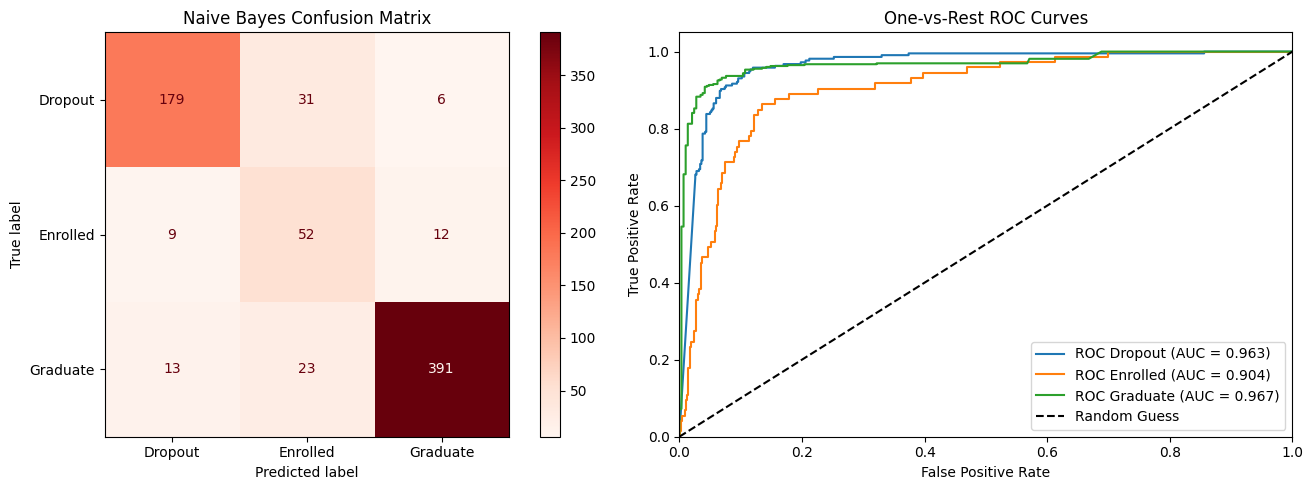

['../models/specialist_dropout_nb.pkl']

In [24]:
from sklearn.metrics import log_loss, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt 

y_pred_nb  = best_nb.predict(Xte_nb)
y_proba_nb = best_nb.predict_proba(Xte_nb)

loss_nb    = log_loss(y_test, y_proba_nb)
roc_auc_ovr = roc_auc_score(y_test, y_proba_nb, multi_class='ovr', average='macro')

print("="*60)
print("Naive Bayes — Dropout Specialist Evaluation Metrics")
print("="*60)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Log Loss  : {loss_nb:.4f}")
print(f"ROC-AUC   : {roc_auc_ovr:.4f} (One-vs-Rest Macro)")
print("-" * 60)

f1_nb = f1_score(y_test, y_pred_nb, average=None)
print(f"F1 per class -> Dropout:{f1_nb[0]:.4f}  Enrolled:{f1_nb[1]:.4f}  Graduate:{f1_nb[2]:.4f}")
print(f"F1 Macro     : {f1_score(y_test, y_pred_nb, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=TARGET_NAMES))

print("-" * 60)
print("Confusion Matrix (Text):")
cm = confusion_matrix(y_test, y_pred_nb)
print(cm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES)
disp.plot(cmap=plt.cm.Reds, ax=axes[0], values_format='d')
axes[0].set_title("Naive Bayes Confusion Matrix")

y_test_bin = pd.get_dummies(y_test).values
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_nb[:, i])
    roc_auc     = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'ROC {TARGET_NAMES[i]} (AUC = {roc_auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('One-vs-Rest ROC Curves')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig('../output/nb_specialist_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

import joblib
joblib.dump(best_nb, '../models/specialist_dropout_nb.pkl')



## FEATURE METADATA

In [25]:
feature_metadata = {
    'xgb_idx': xgb_feat_idx,
    'svm_idx': svm_feat_idx,
    'nb_idx': nb_feat_idx
}
joblib.dump(feature_metadata, '../models/specialist_feature_indices.pkl')


['../models/specialist_feature_indices.pkl']